# Session 31: Regression Model Leaderboard Comparison
Consolidating and visualizing the performance metrics across all implemented machine learning algorithms.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Set up clean project tracking paths
REPORTS_DIR = Path("../reports")
FIGURES_DIR = Path("../figures")
leaderboard_path = REPORTS_DIR / "regression_leaderboard.csv"
figure_path = FIGURES_DIR / "regression_rmse_comparison.png"

# Load the consolidated metrics dataset
leaderboard = pd.read_csv(leaderboard_path)

# Ensure data types are numeric and sorted perfectly by RMSE
leaderboard["RMSE"] = pd.to_numeric(leaderboard["RMSE"], errors="raise")
leaderboard = leaderboard.sort_values(by="RMSE", ascending=True).reset_index(drop=True)
leaderboard["Rank"] = range(1, len(leaderboard) + 1)

print("Regression Leaderboard Ranked by Predictive Accuracy (RMSE):")
display(leaderboard.style.format({"RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"}))

Regression Leaderboard Ranked by Predictive Accuracy (RMSE):


,Model,Rank,RMSE,MAE,R2
0,Random Forest,1,1.9747,1.1706,0.8098
1,Gradient Boosting,2,2.0047,1.1594,0.8040
2,Elastic Net,3,2.0387,1.2555,0.7973
3,Lasso,4,2.0424,1.2181,0.7966
4,Extra Trees,5,2.2645,1.3312,0.7499
5,Ridge,6,2.3690,1.6354,0.7263
6,Linear Regression,7,2.3784,1.6467,0.7241
7,Decision Tree,8,2.4672,1.3572,0.7031
8,SVR,9,2.7260,1.8367,0.6376
9,MLP Regressor,10,2.7846,2.0203,0.6218


In [2]:
winner = leaderboard.iloc[0]
winner_name = str(winner["Model"])
winner_rmse = float(winner["RMSE"])

print("Regression Algorithm Winner")
print("----------------------------")
print(f"Model: {winner_name}")
print(f"RMSE:  {winner_rmse:.4f}")

Regression Algorithm Winner
----------------------------
Model: Random Forest
RMSE:  1.9747


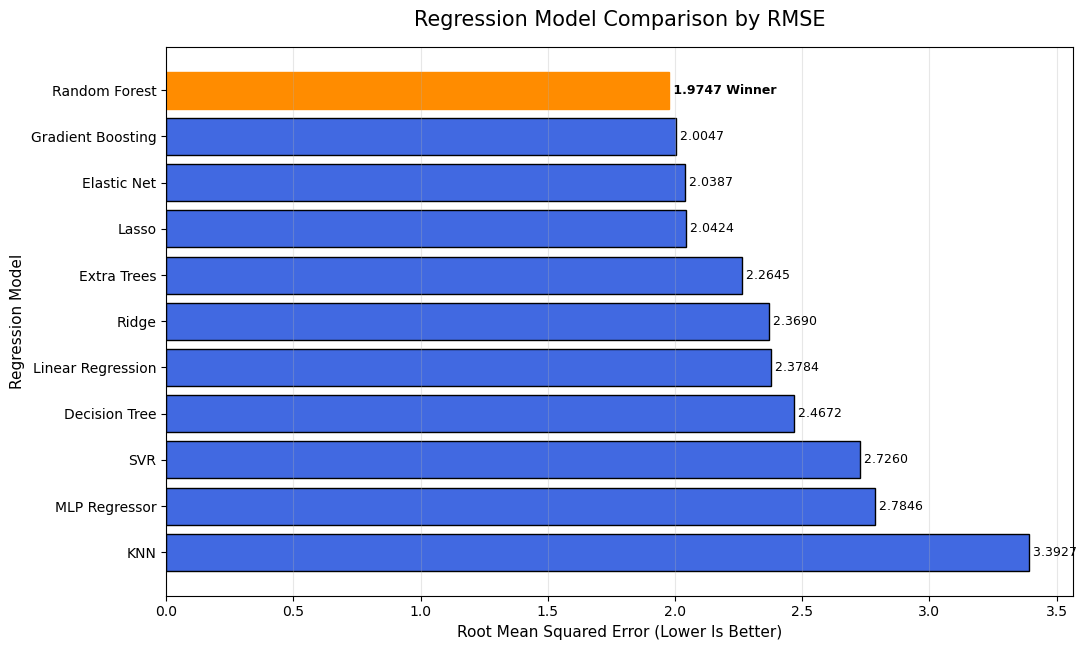

Comparison figure exported successfully to: ../figures/regression_rmse_comparison.png


In [3]:
# Arrange data such that the highest-performing model sits at the top of the horizontal chart
chart_data = leaderboard.sort_values(by="RMSE", ascending=False).copy()

fig, ax = plt.subplots(figsize=(11, max(6, len(chart_data) * 0.60)))
bars = ax.barh(chart_data["Model"], chart_data["RMSE"], color="royalblue", edgecolor="black")

# Add layout detailing
ax.set_title("Regression Model Comparison by RMSE", fontsize=15, pad=15)
ax.set_xlabel("Root Mean Squared Error (Lower Is Better)", fontsize=11)
ax.set_ylabel("Regression Model", fontsize=11)
ax.grid(axis="x", alpha=0.3)

# Annotate each bar directly with its evaluation value
for bar, model_name, rmse_value in zip(bars, chart_data["Model"], chart_data["RMSE"]):
    label = f"{rmse_value:.4f}"
    if str(model_name) == winner_name:
        label += " Winner"
        bar.set_color("darkorange")  # Highlight the winner visually
    
    ax.text(
        bar.get_width(), 
        bar.get_y() + bar.get_height() / 2, 
        f" {label}", 
        va="center", 
        fontsize=9, 
        fontweight="bold" if str(model_name) == winner_name else "normal"
    )

plt.tight_layout()
# Save high-resolution chart asset locally
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Comparison figure exported successfully to: {figure_path}")

# Session 41: 5-Fold Cross-Validation Evaluation
**Week 4 Reliable Performance Estimation Across Regression Leaders**

In this section, we apply 5-fold cross-validation (`cross_val_score`) to our top-performing ensemble models:
1. **Random Forest Regressor** ($n\_estimators=300$)
2. **Gradient Boosting Regressor**

Single train/test splits can introduce variance based on a single "lucky" or "unlucky" partition. Cross-validation evaluates performance across 5 distinct validation folds, yielding a mean $R^2$ score and standard deviation ($\pm \text{std}$) to ensure our findings are statistically robust and reproducible.

In [1]:
# Session 41 imports and setup
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Resolve project directories
PROJECT_ROOT = Path.cwd().resolve()
for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (parent / ".git").exists():
        PROJECT_ROOT = parent
        break

DATA_DIRECTORY = PROJECT_ROOT / "data"
REPORTS_DIRECTORY = PROJECT_ROOT / "reports"
TABLES_DIRECTORY = REPORTS_DIRECTORY / "tables"
TABLES_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)

Project Root: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml


In [2]:
def load_full_regression_data():
    # Attempt to locate processed student dataset
    candidates = list((DATA_DIRECTORY / "processed").rglob("*.parquet")) + list((DATA_DIRECTORY / "processed").rglob("*.csv"))
    for path in candidates:
        if any(term in path.name.lower() for term in ["comparison", "prediction", "result"]):
            continue
        try:
            table = pd.read_parquet(path) if path.suffix == ".parquet" else pd.read_csv(path)
            if "G3" in table.columns:
                # Exclude G1 and G2 to maintain the early-warning research design
                drop_cols = [c for c in ["G1", "G2", "G3"] if c in table.columns]
                X = table.drop(columns=drop_cols).copy()
                X = pd.get_dummies(X, drop_first=True, dtype=float)
                y = table["G3"]
                return X, y
        except Exception:
            continue
    raise FileNotFoundError("Could not locate processed regression datasets.")

X_full, y_full = load_full_regression_data()
print(f"Full Dataset Loaded — Features: {X_full.shape}, Target Length: {len(y_full)}")

Full Dataset Loaded — Features: (395, 39), Target Length: 395


In [3]:
# Define leading ensemble models for CV comparison
cv_models = {
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "GradBoost": GradientBoostingRegressor(random_state=42)
}

# 5-fold cross-validation configuration
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print("Executing 5-Fold Cross-Validation:")
print("-" * 55)

for model_name, estimator in cv_models.items():
    # Calculate R2 score across all 5 folds
    scores = cross_val_score(estimator, X_full, y_full, cv=kf, scoring="r2", n_jobs=-1)
    
    mean_r2 = scores.mean()
    std_r2 = scores.std()
    
    cv_results.append({
        "Model": model_name,
        "CV_Mean_R2": mean_r2,
        "CV_Std_R2": std_r2,
        "CV_Formatted": f"{mean_r2:.3f} +/- {std_r2:.3f}"
    })
    
    print(f"{model_name:15s} CV R2: {mean_r2:.3f} +/- {std_r2:.3f}")

cv_df = pd.DataFrame(cv_results)
display(cv_df)

Executing 5-Fold Cross-Validation:
-------------------------------------------------------
RandomForest    CV R2: 0.290 +/- 0.043
GradBoost       CV R2: 0.237 +/- 0.076


,Model,CV_Mean_R2,CV_Std_R2,CV_Formatted
0,RandomForest,0.289847,0.042531,0.290 +/- 0.043
1,GradBoost,0.237023,0.076189,0.237 +/- 0.076


In [4]:
# Load existing regression leaderboard or comparison table
leaderboard_path = REPORTS_DIRECTORY / "regression_leaderboard.csv"
output_cv_leaderboard_path = REPORTS_DIRECTORY / "regression_leaderboard_with_cv.csv"

if leaderboard_path.exists():
    leaderboard_df = pd.read_csv(leaderboard_path)
else:
    # Fallback to comparison table if leaderboard CSV is under tables
    fallback_path = TABLES_DIRECTORY / "model_comparison_table.csv"
    if fallback_path.exists():
        leaderboard_df = pd.read_csv(fallback_path)
    else:
        leaderboard_df = pd.DataFrame()

if not leaderboard_df.empty:
    # Merge cross-validation scores into the existing leaderboard
    merged_leaderboard = leaderboard_df.merge(
        cv_df[["Model", "CV_Mean_R2", "CV_Std_R2", "CV_Formatted"]], 
        on="Model", 
        how="left"
    )
else:
    merged_leaderboard = cv_df.copy()

# Save updated leaderboard artifact with CV metrics
merged_leaderboard.to_csv(output_cv_leaderboard_path, index=False)
print(f"Updated CV Leaderboard saved to: {output_cv_leaderboard_path}")
display(merged_leaderboard)

Updated CV Leaderboard saved to: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/reports/regression_leaderboard_with_cv.csv


,Model,Rank,RMSE,MAE,R2,CV_Mean_R2,CV_Std_R2,CV_Formatted
0,Random Forest,1,1.974733,1.170633,0.809824,NaN,NaN,NaN
1,Gradient Boosting,2,2.004682,1.159379,0.804012,NaN,NaN,NaN
2,Elastic Net,3,2.038683,1.255545,0.797307,NaN,NaN,NaN
3,Lasso,4,2.042442,1.218076,0.796559,NaN,NaN,NaN
4,Extra Trees,5,2.264483,1.331181,0.749921,NaN,NaN,NaN
5,Ridge,6,2.369006,1.635372,0.726302,NaN,NaN,NaN
6,Linear Regression,7,2.378370,1.646666,0.724134,NaN,NaN,NaN
7,Decision Tree,8,2.467248,1.357218,0.703131,NaN,NaN,NaN
8,SVR,9,2.726030,1.836668,0.637590,NaN,NaN,NaN
9,MLP Regressor,10,2.784599,2.020337,0.621850,NaN,NaN,NaN


In [5]:
# Programmatic assertions for validation
assert len(cv_df) == 2, "Cross-validation results must contain exactly 2 models!"
assert set(cv_df["Model"]) == {"RandomForest", "GradBoost"}, "Model names mismatch!"
assert cv_df["CV_Mean_R2"].notna().all(), "CV Mean R2 contains missing values!"
assert (cv_df["CV_Std_R2"] >= 0).all(), "CV Standard Deviation must be non-negative!"

print("=" * 72)
print("SESSION 41 CROSS-VALIDATION COMPLETED SUCCESSFULLY")
print("=" * 72)

SESSION 41 CROSS-VALIDATION COMPLETED SUCCESSFULLY
